# Does the mixed-state (dissipative) flow improve QAOA on Max-Cut?

A natural question after `quantum_free_energy_flow.ipynb`: the learnable dissipative flow reaches Gibbs states a unitary circuit cannot — does that translate into **better Max-Cut optimization** than standard QAOA?

**A priori caution.** Max-Cut's cost Hamiltonian is *diagonal*, so its ground state (the max cut) is a **pure classical** bitstring — no entropy, no coherence. The dissipative flow's two demonstrated advantages (thermal $T>0$ sampling; coherence for non-commuting $H$) don't obviously apply. This notebook tests it honestly.

**Design.** At matched depth, on a fixed graph, with many random restarts:
- **Standard QAOA($p$)** — the realistic constrained ansatz $\prod_k e^{-i\beta_k\sum X}e^{-i\gamma_k C}$, $2p$ parameters. The reference, and its local-minima behaviour.
- **Unitary flow($L$)** — a general per-layer unitary on the $n$ system qubits (no ancilla) → *expressive but no dissipation*.
- **Dissipative flow($L$)** — the same per-layer unitary **plus a fresh ancilla reset each layer** → adds cooling.

All minimise the energy $\langle -\mathrm{cut}\rangle$ (the $T\!\to\!0$ free energy). Two comparisons matter:
1. **flows vs QAOA** — expressivity (note: the flows use *far* more parameters, so this is not a parameter-matched test);
2. **unitary vs dissipative** — same generator size $\pm$ ancilla, so this *isolates the effect of dissipation itself*.

Metrics over restarts: mean approximation ratio (typical-run quality ⇒ local-minima robustness), best-of-$K$, success rate (within $1\%$ of optimum), and spread.

In [1]:
import numpy as np, torch, networkx as nx, matplotlib.pyplot as plt, functools, warnings, time
warnings.filterwarnings("ignore"); print = functools.partial(print, flush=True)
torch.set_default_dtype(torch.float64); np.random.seed(0); torch.manual_seed(0)
plt.rcParams.update({"font.size": 11}); C128 = torch.complex128
N, M = 6, 1; dS, dA = 2**N, 2**M

def bitm(n):
    xs = np.arange(2**n); return ((xs[:, None] >> (n-1-np.arange(n))[None, :]) & 1).astype(np.int8)
BITS = bitm(N)
def cutvals(edges, n):
    C = np.zeros(2**n)
    for i, j in edges: C += (BITS[:, i] != BITS[:, j])
    return C
G = nx.random_regular_graph(3, N, seed=1); cut = cutvals(list(G.edges()), N)
Ct = torch.tensor(cut); MX = cut.max(); Hdiag = -Ct
print(f"n={N}, {G.number_of_edges()} edges (3-regular), max-cut={MX:.0f}")

# ── standard QAOA (constrained ansatz), batched over restarts ──
def mixer(psi, beta, n):
    k = psi.shape[0]; c = torch.cos(beta).to(psi.dtype); s = (-1j*torch.sin(beta)).to(psi.dtype)
    t = psi.reshape((k,)+(2,)*n); cc = c.view((k,)+(1,)*(n-1)); ss = s.view((k,)+(1,)*(n-1))
    for q in range(n):
        t = torch.movedim(t, q+1, 1); a = t[:, 0].clone(); b = t[:, 1].clone()
        t = torch.movedim(torch.stack([cc*a+ss*b, ss*a+cc*b], 1), 1, q+1)
    return t.reshape(k, -1)
def qaoa_cut(ang, n, p):
    k = ang.shape[0]; g = ang[:, :p]; be = ang[:, p:]
    psi = torch.ones((k, 2**n), dtype=C128)/np.sqrt(2**n)
    for l in range(p):
        psi = torch.exp(-1j*g[:, l:l+1]*Ct[None, :])*psi; psi = mixer(psi, be[:, l], n)
    return (psi.conj()*psi).real @ Ct
def run_qaoa(p, K=30, steps=300, lr=0.05, seed=0):
    torch.manual_seed(seed); ang = (torch.rand(K, 2*p)*2-1).requires_grad_(True)
    opt = torch.optim.Adam([ang], lr=lr)
    for _ in range(steps):
        opt.zero_grad(); (-(qaoa_cut(ang, N, p)).sum()).backward(); opt.step()
    with torch.no_grad(): return (qaoa_cut(ang, N, p)/MX).numpy()

# ── general unitary / dissipative flows (density matrix), per-restart ──
e00 = torch.zeros(dA, dA, dtype=C128); e00[0, 0] = 1.0
def herm(pre, pim): A = torch.complex(pre, pim); return A + A.conj().T
def energy(rho): return (torch.diagonal(rho).real * Hdiag).sum()
def coherent_flow(ps, rho0):
    rho = rho0
    for pre, pim in ps:
        U = torch.matrix_exp(1j*herm(pre, pim)); rd = torch.kron(rho, e00); rd = U @ rd @ U.conj().T
        rho = torch.einsum('saqa->sq', rd.reshape(dS, dA, dS, dA))
    return rho
def unitary_flow(ps, rho0):
    rho = rho0
    for pre, pim in ps:
        U = torch.matrix_exp(1j*herm(pre, pim)); rho = U @ rho @ U.conj().T
    return rho
psi0 = torch.ones(dS, dtype=C128)/np.sqrt(dS); rho0 = torch.outer(psi0, psi0.conj())
def mk(dim, L, seed, s=0.1):
    g = torch.Generator().manual_seed(seed)
    return [[(torch.randn(dim, dim, generator=g)*s).requires_grad_(True),
             (torch.randn(dim, dim, generator=g)*s).requires_grad_(True)] for _ in range(L)]
def run_flow(flow, dim, L, K=10, steps=150, lr=0.05):
    outs = []
    for r in range(K):
        ps = mk(dim, L, seed=r); opt = torch.optim.Adam([q for pl in ps for q in pl], lr=lr)
        for _ in range(steps):
            opt.zero_grad(); energy(flow(ps, rho0)).backward(); opt.step()
        with torch.no_grad(): outs.append(float(-energy(flow(ps, rho0))/MX))
    return np.array(outs)

def nparams_qaoa(p): return 2*p
def nparams_flow(L, dim): return L*2*dim*dim
print(f"params: QAOA(p=3)={nparams_qaoa(3)},  unitary-flow(L=3)={nparams_flow(3,dS)},  dissipative-flow(L=3)={nparams_flow(3,dS*dA)}")

n=6, 9 edges (3-regular), max-cut=9


params: QAOA(p=3)=6,  unitary-flow(L=3)=24576,  dissipative-flow(L=3)=98304


## Experiment G1 — local-minima robustness (random restarts)

For each method at depth $p=L\in\{2,3\}$ we run many random restarts on the same graph and look at the *distribution* of final approximation ratios. A method plagued by local minima shows a low, spread-out cloud; a robust one clusters near the optimum.

depth 2:


          QAOA: mean=0.861 best=0.891 success≥0.99=0.00 std=0.036


       unitary: mean=0.985 best=0.999 success≥0.99=0.60 std=0.017


   dissipative: mean=0.967 best=0.999 success≥0.99=0.40 std=0.057


depth 3:


          QAOA: mean=0.944 best=0.984 success≥0.99=0.00 std=0.034


       unitary: mean=0.969 best=0.998 success≥0.99=0.50 std=0.052


   dissipative: mean=0.958 best=0.993 success≥0.99=0.20 std=0.047


(trained in 188s)


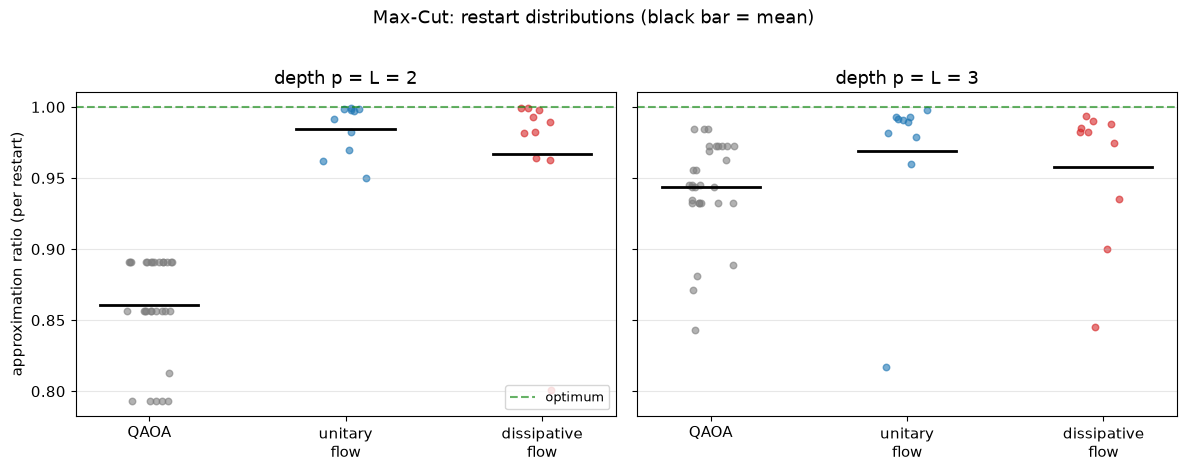

In [2]:
res = {}; t0 = time.time()
for p in (2, 3):
    res[p] = {"QAOA": run_qaoa(p, K=30), "unitary": run_flow(unitary_flow, dS, p, K=10),
              "dissipative": run_flow(coherent_flow, dS*dA, p, K=10)}
    print(f"depth {p}:")
    for m in ("QAOA", "unitary", "dissipative"):
        r = res[p][m]; print(f"  {m:>12}: mean={r.mean():.3f} best={r.max():.3f} success≥0.99={np.mean(r>=0.99):.2f} std={r.std():.3f}")
print(f"(trained in {time.time()-t0:.0f}s)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
cols = {"QAOA": "#7f7f7f", "unitary": "#1f77b4", "dissipative": "#d62728"}
for c, p in enumerate((2, 3)):
    for xi, m in enumerate(("QAOA", "unitary", "dissipative")):
        r = res[p][m]; x = xi + np.random.uniform(-0.12, 0.12, len(r))
        ax[c].scatter(x, r, s=22, color=cols[m], alpha=.6)
        ax[c].plot([xi-0.25, xi+0.25], [r.mean()]*2, color="black", lw=2)
    ax[c].axhline(1.0, ls="--", color="green", alpha=.6, label="optimum")
    ax[c].set_xticks(range(3)); ax[c].set_xticklabels(["QAOA", "unitary\nflow", "dissipative\nflow"])
    ax[c].set_title(f"depth p = L = {p}"); ax[c].grid(alpha=.3, axis="y")
ax[0].set_ylabel("approximation ratio (per restart)"); ax[0].legend(fontsize=9, loc="lower right")
plt.suptitle("Max-Cut: restart distributions (black bar = mean)", y=1.02)
plt.tight_layout(); plt.savefig("mc_expG1.png", dpi=130, bbox_inches="tight"); plt.show()

## Experiment G2 — capacity (depth) sweep

If dissipation genuinely helped, it might reach the optimum at *lower* depth than the pure-unitary flow. We sweep depth and plot best-of-$K$ and mean approximation ratio for all three methods.

L=1: QAOA 0.692/0.692  unitary 0.996/1.000  dissipative 0.960/1.000


L=2: QAOA 0.861/0.891  unitary 0.991/1.000  dissipative 0.961/0.999


L=3: QAOA 0.944/0.984  unitary 0.933/1.000  dissipative 0.958/0.996


(swept in 120s)


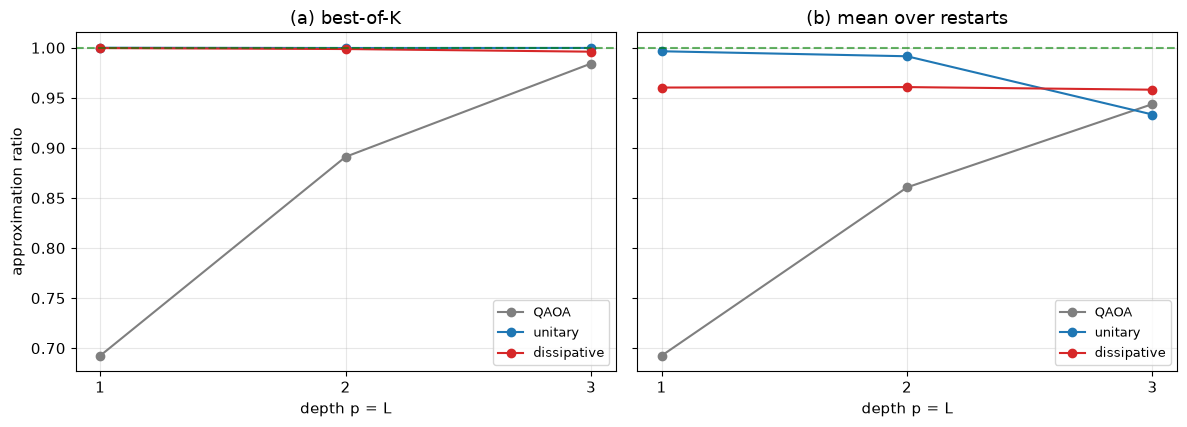

In [3]:
depths = [1, 2, 3]; sweep = {"QAOA": [], "unitary": [], "dissipative": []}; t0 = time.time()
for L in depths:
    rq = run_qaoa(L, K=30); ru = run_flow(unitary_flow, dS, L, K=6, steps=120); rd = run_flow(coherent_flow, dS*dA, L, K=6, steps=120)
    sweep["QAOA"].append((rq.mean(), rq.max())); sweep["unitary"].append((ru.mean(), ru.max())); sweep["dissipative"].append((rd.mean(), rd.max()))
    print(f"L={L}: QAOA {rq.mean():.3f}/{rq.max():.3f}  unitary {ru.mean():.3f}/{ru.max():.3f}  dissipative {rd.mean():.3f}/{rd.max():.3f}")
print(f"(swept in {time.time()-t0:.0f}s)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
cols = {"QAOA": "#7f7f7f", "unitary": "#1f77b4", "dissipative": "#d62728"}
for m in ("QAOA", "unitary", "dissipative"):
    ax[0].plot(depths, [v[1] for v in sweep[m]], "o-", color=cols[m], label=m)
    ax[1].plot(depths, [v[0] for v in sweep[m]], "o-", color=cols[m], label=m)
for a, t in zip(ax, ("(a) best-of-K", "(b) mean over restarts")):
    a.axhline(1.0, ls="--", color="green", alpha=.6); a.set_xlabel("depth p = L"); a.set_xticks(depths)
    a.set_title(t); a.grid(alpha=.3); a.legend(fontsize=9)
ax[0].set_ylabel("approximation ratio")
plt.tight_layout(); plt.savefig("mc_expG2.png", dpi=130, bbox_inches="tight"); plt.show()

## Summary — an honest negative control

**Does the mixed-state (dissipative) flow improve QAOA on Max-Cut? No — not via dissipation.**

1. **Expressive flows beat standard QAOA, but that's parameters, not dissipation.** Standard QAOA is limited by both depth and local minima (mean $<$ best, success $=0$ at $p=2,3$; e.g. $0.861$/$0.944$ mean at $p=2$/$3$). The flows reach the optimum (best-of-$K=1.0$) from as little as $L=1$ — but they carry $\sim\!4\times10^3$–$1.6\times10^4$ *more parameters* (QAOA $p{=}3$: 6 params; unitary flow: 24{,}576; dissipative flow: 98{,}304). This is an expressivity gap, not a fair NISQ comparison.

2. **Dissipation specifically does not help — it mildly hurts.** The clean, matched comparison (unitary vs dissipative, same generator size $\pm$ ancilla) has the dissipative flow *below* the unitary flow at every depth: mean $0.967$ vs $0.985$ and success $0.40$ vs $0.60$ at $p=2$; $0.958$ vs $0.969$ at $p=3$. Because Max-Cut's optimum is a **pure classical** state, the entropy-generating ancilla machinery is a liability at $T\!\to\!0$: it enlarges and roughens the landscape without helping reach a pure target.

**Why this is the *expected* answer, and why it sharpens the thesis.** Max-Cut has a *diagonal* cost Hamiltonian, so its ground state carries neither entropy nor coherence — exactly the two things the dissipative/coherent flow is good at (`quantum_free_energy_flow`, `quantum_diffusion_coherent`). The mixed-state flow's advantage is real but lives in **thermal sampling ($T>0$)** and **coherent Gibbs states (non-commuting $H$)**, *not* in pure combinatorial optimisation. If one wants to help QAOA specifically, the promising route is *engineered cooling that lowers energy* (a Davies/Lindblad generator with detailed balance) rather than the generic entropy-injecting ancilla reset used here — the natural subject of the continuous-time Lindblad follow-up.